In [1]:
# Step 1: Import necessary libraries
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("master_df.csv")
df['Date'] = pd.to_datetime(df['Date'], format='%Y-%m-%d')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5219 entries, 0 to 5218
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   IWM_Close   5219 non-null   float64       
 1   QQQ_Close   5219 non-null   float64       
 2   SPY_Close   5219 non-null   float64       
 3   IWM_High    5219 non-null   float64       
 4   QQQ_High    5219 non-null   float64       
 5   SPY_High    5219 non-null   float64       
 6   IWM_Low     5219 non-null   float64       
 7   QQQ_Low     5219 non-null   float64       
 8   SPY_Low     5219 non-null   float64       
 9   IWM_Open    5219 non-null   float64       
 10  QQQ_Open    5219 non-null   float64       
 11  SPY_Open    5219 non-null   float64       
 12  IWM_Volume  5219 non-null   float64       
 13  QQQ_Volume  5219 non-null   float64       
 14  SPY_Volume  5219 non-null   float64       
 15  VIX         5219 non-null   float64       
 16  Date        5219 non-nul

In [3]:
# Step 2: Create a copy of the dataframe and explore the data
print("DataFrame shape:", df.shape)
print("\nFirst few rows:")
df.head()

DataFrame shape: (5219, 17)

First few rows:


,IWM_Close,QQQ_Close,SPY_Close,IWM_High,QQQ_High,SPY_High,IWM_Low,QQQ_Low,SPY_Low,IWM_Open,QQQ_Open,SPY_Open,IWM_Volume,QQQ_Volume,SPY_Volume,VIX,Date
0,48.436916,33.738789,81.847130,49.422176,34.413565,82.840453,48.179233,33.627749,81.574985,49.335020,34.242735,82.704378,16062600.0,100970900.0,55748000.0,14.08,2005-01-03
1,47.398586,33.123783,80.846992,48.569529,33.943766,82.010405,47.315218,32.927330,80.581653,48.531637,33.883973,81.955975,27450000.0,136623200.0,69167600.0,13.98,2005-01-04
2,46.451256,32.918819,80.289108,47.474410,33.277560,81.132751,46.451256,32.859029,80.282303,47.345570,33.038399,80.785767,29884200.0,127925500.0,65667300.0,14.09,2005-01-05
3,46.697544,32.756512,80.697357,47.140910,33.064005,81.064752,46.401964,32.747972,80.459233,46.739226,32.995675,80.581697,23061200.0,102934600.0,47814700.0,13.58,2005-01-06
4,46.178383,32.927341,80.581665,46.951433,33.200668,81.119149,46.151857,32.636932,80.370750,46.803645,32.935885,80.942254,20906200.0,123104000.0,55847700.0,13.49,2005-01-07


In [4]:
# Step 3: Create features - momentum and VIX-based features
# Momentum features
df['SPY_momentum_5d'] = df['SPY_Close'].pct_change(5)
df['SPY_momentum_10d'] = df['SPY_Close'].pct_change(10)

# VIX features (current level and changes)
df['VIX_current'] = df['VIX']
df['VIX_change_1d'] = df['VIX'].pct_change()
df['VIX_change_5d'] = df['VIX'].pct_change(5)

# Volume features (additional potential predictors)
df['SPY_volume_change_1d'] = df['SPY_Volume'].pct_change()
df['SPY_volume_change_5d'] = df['SPY_Volume'].pct_change(5)

# Target variable: Next day return
df['target_future_return'] = df['SPY_Close'].pct_change().shift(-1)

In [5]:
# Step 4: Check for correlations between features and target
feature_columns = [
    'SPY_momentum_5d',
    'SPY_momentum_10d',
    'VIX_current',
    'VIX_change_1d',
    'VIX_change_5d',
    'SPY_volume_change_1d',
    'SPY_volume_change_5d'
]

# Calculate correlations with target
correlations = df[feature_columns + ['target_future_return']].corr()['target_future_return'].sort_values(ascending=False)
print("Correlations with target future return:")
print(correlations)

Correlations with target future return:
target_future_return    1.000000
VIX_change_1d           0.051907
VIX_change_5d           0.046760
VIX_current             0.042067
SPY_volume_change_1d    0.013611
SPY_volume_change_5d    0.009087
SPY_momentum_10d       -0.051507
SPY_momentum_5d        -0.078212
Name: target_future_return, dtype: float64


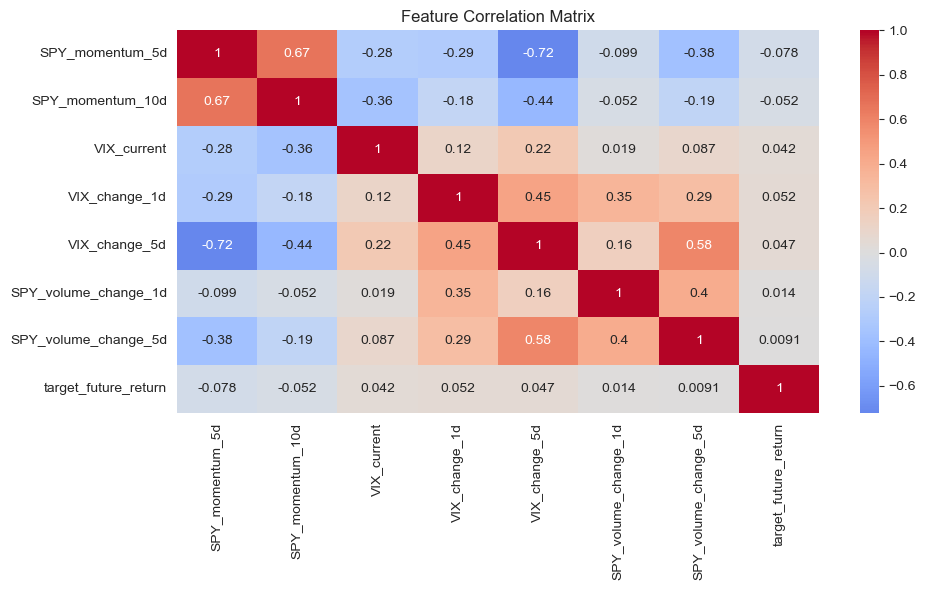

In [6]:
# Step 5: Visualize correlations
plt.figure(figsize=(10, 6))
corr_matrix = df[feature_columns + ['target_future_return']].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0)
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

In [7]:
# Step 6: Prepare data for modeling - drop NaN values created by pct_change
df_clean = df[['Date', 'target_future_return'] + feature_columns].dropna()

print(f"Original data shape: {df.shape}")
print(f"Clean data shape: {df_clean.shape}")
print(f"Number of samples for modeling: {len(df_clean)}")

Original data shape: (5219, 25)
Clean data shape: (5208, 9)
Number of samples for modeling: 5208


In [8]:
# Step 7: Split features (X) and target (y)
X = df_clean[feature_columns]
y = df_clean['target_future_return']

print("Feature matrix shape:", X.shape)
print("Target vector shape:", y.shape)

Feature matrix shape: (5208, 7)
Target vector shape: (5208,)


In [9]:
# Step 8: Train the multiple linear regression model
model = LinearRegression()
model.fit(X, y)

# Make predictions
y_pred = model.predict(X)

# Print model coefficients
print("Model Coefficients:")
for feature, coef in zip(feature_columns, model.coef_):
    print(f"{feature}: {coef:.6f}")
print(f"Intercept: {model.intercept_:.6f}")

Model Coefficients:
SPY_momentum_5d: -0.049254
SPY_momentum_10d: 0.004945
VIX_current: 0.000032
VIX_change_1d: 0.006360
VIX_change_5d: -0.002124
SPY_volume_change_1d: 0.000133
SPY_volume_change_5d: -0.000590
Intercept: 0.000010


In [10]:
# Step 9: Evaluate model performance
mse = mean_squared_error(y, y_pred)
r2 = r2_score(y, y_pred)

print("Model Performance Metrics:")
print(f"Mean Squared Error: {mse:.6f}")
print(f"R-squared: {r2:.4f}")
print(f"Root Mean Squared Error: {np.sqrt(mse):.6f}")

# Compare with simple mean prediction (baseline)
baseline_pred = np.full_like(y, y.mean())
baseline_mse = mean_squared_error(y, baseline_pred)
print(f"Baseline MSE (using mean): {baseline_mse:.6f}")
print(f"Model improvement over baseline: {((baseline_mse - mse) / baseline_mse * 100):.2f}%")

Model Performance Metrics:
Mean Squared Error: 0.000144
R-squared: 0.0086
Root Mean Squared Error: 0.011999
Baseline MSE (using mean): 0.000145
Model improvement over baseline: 0.86%


In [11]:
# Step 10: Create comprehensive results dataframe
results_df = pd.DataFrame({
    'Date': df_clean['Date'],
    'SPY_Close': df.loc[df_clean.index, 'SPY_Close'],  # Get corresponding SPY prices
    'actual_future_return': y,
    'predicted_return': y_pred,
    'prediction_error': y_pred - y,
    'absolute_error': np.abs(y_pred - y)
})

# Add all features used in the model
for feature in feature_columns:
    results_df[feature] = df_clean[feature]

# Add model coefficients and predictions
results_df['trading_signal'] = np.where(y_pred > 0, 'BUY', 'SELL')
results_df['correct_direction'] = (y * y_pred) > 0  # True if both same sign

print("Results dataframe preview:")
results_df.head(100)

Results dataframe preview:


,Date,SPY_Close,actual_future_return,predicted_return,prediction_error,absolute_error,SPY_momentum_5d,SPY_momentum_10d,VIX_current,VIX_change_1d,VIX_change_5d,SPY_volume_change_1d,SPY_volume_change_5d,trading_signal,correct_direction
10,2005-01-18,81.282410,-0.010462,0.000360,0.010823,0.010823,0.003949,-0.006900,12.47,0.003218,-0.057445,0.365412,0.014646,BUY,False
11,2005-01-19,80.431999,-0.006091,0.000825,0.006916,0.006916,0.000338,-0.005133,13.18,0.056937,-0.000758,-0.052495,-0.138207,BUY,False
12,2005-01-20,79.942108,-0.006128,0.001020,0.007148,0.007148,-0.009024,-0.004322,13.83,0.049317,0.101115,0.324950,-0.009230,BUY,False
13,2005-01-21,79.452263,-0.001969,0.000637,0.002606,0.002606,-0.007142,-0.015429,14.36,0.038322,0.118380,-0.123372,0.137257,BUY,False
14,2005-01-24,79.295807,0.002831,0.000610,-0.002222,0.002222,-0.014293,-0.015957,14.65,0.020195,0.178600,-0.074707,0.390398,BUY,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
105,2005-06-03,82.066170,-0.000915,0.000402,0.001317,0.001317,0.000833,0.007210,12.15,0.026182,-0.007353,0.536335,0.410189,BUY,False
106,2005-06-06,81.991058,0.000749,0.000241,-0.000508,0.000508,-0.001746,0.007724,12.28,0.010700,0.010700,-0.409070,0.465533,BUY,True
107,2005-06-07,82.052490,-0.001831,0.000149,0.001980,0.001980,0.005440,0.002922,12.39,0.008958,-0.067720,0.844880,0.533093,BUY,False
108,2005-06-08,81.902214,0.004754,0.000926,-0.003828,0.003828,-0.004897,0.003431,12.70,0.025020,0.027508,-0.295033,-0.326526,BUY,True


In [12]:
# Step 11: Analyze directional accuracy
direction_accuracy = results_df['correct_direction'].mean() * 100
print(f"Direction Prediction Accuracy: {direction_accuracy:.2f}%")

# Analyze performance by VIX levels
results_df['VIX_level'] = pd.cut(results_df['VIX_current'],
                                bins=[0, 15, 20, 25, 50],
                                labels=['Low', 'Medium', 'High', 'Very High'])

print("\nPerformance by VIX Level:")
vix_performance = results_df.groupby('VIX_level').agg({
    'correct_direction': 'mean',
    'absolute_error': 'mean',
    'actual_future_return': 'std',
},
observed=False)
print(vix_performance)

Direction Prediction Accuracy: 52.52%

Performance by VIX Level:
           correct_direction  absolute_error  actual_future_return
VIX_level                                                         
Low                 0.517504        0.004224              0.005698
Medium              0.521768        0.006624              0.008717
High                0.525088        0.008825              0.011535
Very High           0.552598        0.014113              0.018672


C:\Users\puyan\AppData\Local\Temp\ipykernel_17776\2214451044.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  vix_performance = results_df.groupby('VIX_level').agg({


In [13]:
# Step 12: Save results to CSV
results_df.to_csv('multi_lin_reg_with_momentum_and_VIX.csv', index=False)
print("Results saved to 'multi_lin_reg_with_momentum_and_VIX.csv'")

# Save model summary to text file
with open('model_summary.txt', 'w') as f:
    f.write("Multiple Linear Regression Model Summary\n")
    f.write("========================================\n\n")
    f.write("Features used:\n")
    for feature in feature_columns:
        f.write(f"- {feature}\n")
    f.write(f"\nR-squared: {r2:.4f}\n")
    f.write(f"MSE: {mse:.6f}\n")
    f.write(f"Direction Accuracy: {direction_accuracy:.2f}%\n")
    f.write("\nCoefficients:\n")
    for feature, coef in zip(feature_columns, model.coef_):
        f.write(f"{feature}: {coef:.6f}\n")
    f.write(f"Intercept: {model.intercept_:.6f}\n")

print("Model summary saved to 'model_summary.txt'")

Results saved to 'multi_lin_reg_with_momentum_and_VIX.csv'
Model summary saved to 'model_summary.txt'


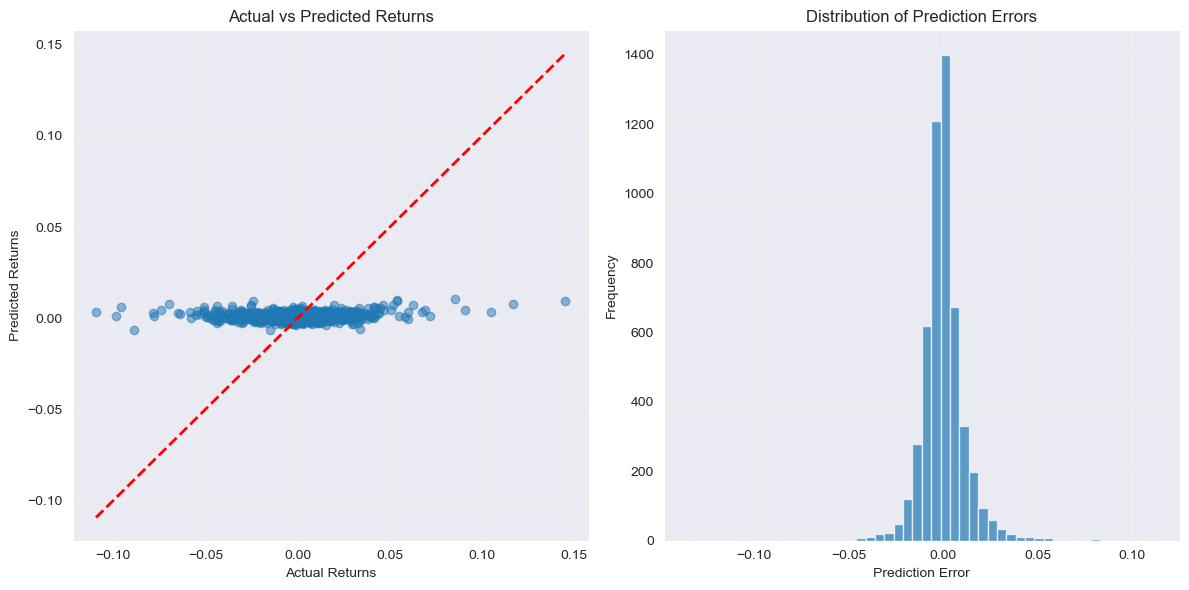

In [14]:
# Step 13: Optional - Plot actual vs predicted returns
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.scatter(y, y_pred, alpha=0.5)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2)
plt.xlabel('Actual Returns')
plt.ylabel('Predicted Returns')
plt.title('Actual vs Predicted Returns')
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.hist(results_df['prediction_error'], bins=50, alpha=0.7)
plt.xlabel('Prediction Error')
plt.ylabel('Frequency')
plt.title('Distribution of Prediction Errors')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()